Preprocessing 

In [1]:
import pandas as pd
import numpy as np



train= pd.read_csv('claims_train.csv')
test = pd.read_csv('claims_test.csv')

#Cleaning weird values that found during cleaning
train = train[train['Exposure'] <= 1].copy()
test =test[test['Exposure']<=1].copy()

# Adding Risk column
train['Risk'] = train['ClaimNb'] / train['Exposure'] 
test['Risk'] =  test['ClaimNb'] / test['Exposure']

#Encoding
train_encoded=pd.get_dummies(train, columns=['VehBrand', 'VehGas', 'Region'], drop_first=True)#Encoding categorical values
area_map={'A':1,'B':2,'C':3,'D':4,'E':5,'F':6}
train_encoded['Area']=train_encoded['Area'].map(area_map)

test_encoded=pd.get_dummies(test, columns=['VehBrand', 'VehGas', 'Region'], drop_first=True)#Encoding categorical values
area_map={'A':1,'B':2,'C':3,'D':4,'E':5,'F':6}
test_encoded['Area']=test_encoded['Area'].map(area_map)

w=train['Exposure']
X_train=train_encoded.drop(columns=['ClaimNb','Exposure', 'IDpol','Risk'])
y_train=train_encoded['ClaimNb']

X_test=test_encoded.drop(columns=['ClaimNb','Exposure', 'IDpol','Risk'])
y_test=test_encoded['ClaimNb']


Training the model 

In [5]:
import xgboost as xgb
from sklearn.metrics import  recall_score, precision_score

xgb = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train, sample_weight=w)
y_pred=xgb.predict(X_test)

from sklearn.metrics import mean_poisson_deviance
eps = 1e-9
y_pred_safe = np.clip(y_pred, eps, None)
mpd_model = mean_poisson_deviance(y_test, y_pred_safe)

print("Model Poisson Deviance:", mpd_model)

df=pd.DataFrame({"y_test":y_test, "y_pred":y_pred})
df["bucket"] = pd.qcut(df.y_pred, q=10, labels=False)
tab_xgboost=df.groupby("bucket")["y_test"].mean()



Model Poisson Deviance: 0.3073713481426239


Lift seperation of top 10 % from average

In [8]:
overall_mean= y_test.mean()
xgboost_lift = tab_xgboost.iloc[-1] / overall_mean
print(xgboost_lift)

2.726458662062595


In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_true_bin= (y_test >0).astype(int)
y_true_bin[y_true_bin >0]

precision, recall, thresholds = precision_recall_curve(y_true_bin, y_pred)
ap_xgb = average_precision_score(y_true_bin, y_pred)

print(ap_xgb)

0.11518290155985678


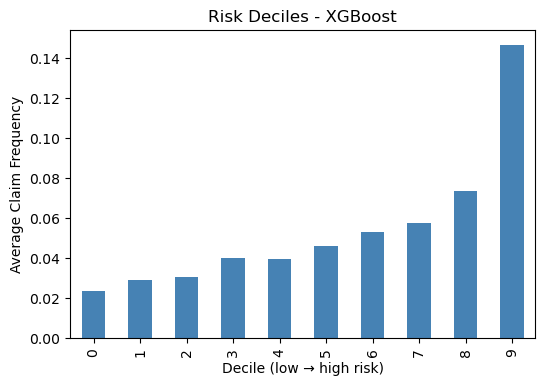

In [10]:
import matplotlib.pyplot as plt
def decile_plot(y_true, y_pred, model_name):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["decile"] = pd.qcut(df["y_pred"], 10, labels=False)

    deciles = df.groupby("decile")["y_true"].mean()

    plt.figure(figsize=(6,4))
    deciles.plot(kind="bar", color="steelblue")
    plt.title(f"Risk Deciles - {model_name}")
    plt.ylabel("Average Claim Frequency")
    plt.xlabel("Decile (low → high risk)")
    plt.show()
decile_plot(y_test, y_pred, model_name= 'XGBoost')

C:\Users\shere\AppData\Local\Temp\ipykernel_27996\3601635168.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = df.groupby("bucket").agg(


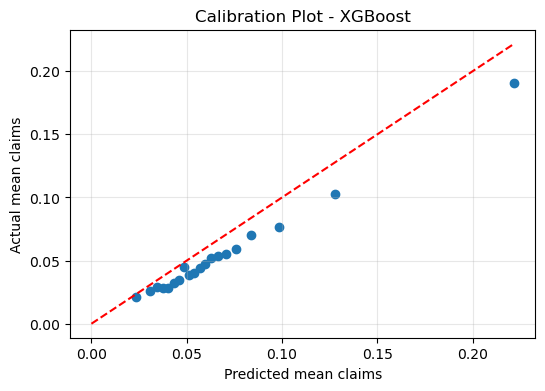

In [12]:
def calibration_plot(y_true, y_pred, model_name, bins=20):
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df["bucket"] = pd.qcut(df["y_pred"], bins, duplicates='drop')
    
    calib = df.groupby("bucket").agg(
        predicted=("y_pred","mean"),
        actual=("y_true","mean")
    )

    plt.figure(figsize=(6,4))
    plt.scatter(calib["predicted"], calib["actual"], label=model_name)
    max_val = max(calib["predicted"].max(), calib["actual"].max())
    plt.plot([0, max_val], [0, max_val], "r--")
    plt.xlabel("Predicted mean claims")
    plt.ylabel("Actual mean claims")
    plt.title(f"Calibration Plot - {model_name}")
    plt.grid(alpha=0.3)
    plt.show()
calibration_plot(y_test, y_pred, "XGBoost")